In [ ]:
#import libraries and csv
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
df = pd.read_csv('https://raw.githubusercontent.com/PandaKnee/Rod-Pump-Failure-Analysis/refs/heads/main/rodpump_dataset.csv')

In [ ]:
### Preprocessing/Cleaning/EDA
print(df.head())

# count datatypes, print dimensions
print(df.dtypes.value_counts())
print(df.shape)
print(df.columns)

# instructed to drop:
df.drop(['manual_scale','REPORTTO','FAILSTART'], axis=1, inplace=True)

# check duplicates
df = df.drop_duplicates(subset=['roduid','UWI','NODEID','IDWELL','tbguid'])
print(df.shape)

# one-hot encoding of target variable
df[['FAILED']] = df[['FAILURETYPE']].notnull().astype('int64')

# change ordering of categorical levels
df['FAILURETYPE'] = pd.Categorical(df['FAILURETYPE'], categories=['NOFAIL', 'Tubing', 'Sucker Rod Pump', 'Rods'], ordered=True)

# convert incorrect data types
df['ROUTE'] = df['ROUTE'].astype('object')
df['rod_has_guides'] = df['rod_has_guides'].astype('int64')
df['lifetime_start'] = pd.to_datetime(df['lifetime_start'])
df['lifetime_end'] = pd.to_datetime(df['lifetime_end'])

# Feature engineering: time data
df['lifetime_duration_days'] = ((df['lifetime_end'] - df['lifetime_start']) / pd.Timedelta(days=1)).round(2)

# Data Imputation: impute missing values of Failure Type variable with "NOFAIL" & nulls in categorical data with 'UNKNOWN'
df[['FAILURETYPE']] = df[['FAILURETYPE']].fillna(value="NOFAIL")
df[['FAILURETYPE','FAILED']].head(8)
df[['bha_configuration', 'wellbore_category', 'packer_vs_tac', 'rod_sinker_type', 'rod_make','rod_apigrade', 'DESANDDEGAS_TYP']] = df[['bha_configuration', 'wellbore_category', 'packer_vs_tac','rod_sinker_type', 'rod_make','rod_apigrade', 'DESANDDEGAS_TYP']].fillna(value="UNKNOWN")

# separate df into data types
df_num = df.select_dtypes(include=('int64','float64','datetime64[ns]'))
df_categorical = df.select_dtypes(include='object')

# Fill categorical data in numerical feature to null
df['pump_bore'] = df['pump_bore'].replace('Other', None)

### Optional: encode rod_make to simpler values
# categories = df['rod_make'].value_counts().index
# labels = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
# rod_make_mapping = dict(zip(categories, labels))
# df['rod_make'] = df['rod_make'].map(rod_make_mapping)
# df['rod_make'].value_counts()

                   roduid          UWI              NODEID  \
0  GB27GKBE51029074693667  175-58-0111    box-child-doctor   
1  GB53OEVX46438297645035  333-68-3523       outside-worry   
2  GB95BPWW35640301552066  165-51-5897   near-learn-simply   
3  GB79UEDN31454825972680  543-56-3494   sea-improve-place   
4  GB20XCTM13691331349509  391-37-2039  personal-candidate   

               IDWELL                  tbguid           lifetime_start  \
0  GPVO63973435661154  GB55QFGB46756147811400  2014-05-02 00:00:00.000   
1  ZAYT33358197650329  GB29QCCC14341267287129  2018-01-28 14:00:00.000   
2  FNVL11432909873086  GB02DJAW44801752494129  2011-09-14 00:00:00.000   
3  JOKL33317998159514  GB84GHPH97287631470412  2016-01-12 09:00:00.000   
4  XOSU92041716672870  GB08VYTX61977431827206  2018-06-14 13:00:00.000   

              lifetime_end        IDRECJOBPULL         REPORTTO  \
0  2019-01-04 10:00:00.000  FGNB86581338411987           Tubing   
1  2019-05-17 12:00:00.000  XRYU81281518151403  

In [ ]:
### Pearson Correlation Analysis
# correlation heatmap
sns.heatmap(abs(df_num.corr()), vmin=0, vmax=1)
# r^2 table
(df_num.corr()**2).round(4)

# Find highly correlated pairs, strong correlations (|corr| > 0.8)
corr = df_num.corr()
high_corr_mask = corr.abs() > 0.8
filtered_corr = corr.where(high_corr_mask)
filtered_corr = filtered_corr.mask(np.eye(len(corr), dtype=bool))
high_corr_pairs = filtered_corr.stack().reset_index()
high_corr_pairs.columns = ['Column 1', 'Column 2', 'Correlation']
high_corr_pairs = high_corr_pairs[high_corr_pairs['Correlation'].abs() > 0.8]
print(high_corr_pairs)

# Check if liquid = water + oil
df['diff'] = df["AVG_LIQUID_VOLUME"].fillna(0) - (df["AVG_WATER_VOLUME"].fillna(0) + df["AVG_OIL_VOLUME"].fillna(0))
liquids = df[df['diff'] > 0.01].sort_values(by = 'diff', ascending = False)
print(liquids[['AVG_WATER_VOLUME','AVG_OIL_VOLUME','AVG_LIQUID_VOLUME']].head())
# Correct outlier
df.at[2107, 'AVG_LIQUID_VOLUME'] = (df.loc[2107, 'AVG_WATER_VOLUME'] + df.loc[2107, 'AVG_OIL_VOLUME'])
df.drop('diff', axis = 1, inplace = True)
df = df[df['AVG_LIQUID_VOLUME'].notna()]

# Feature engineering for liquid prop.
df['WaterRatio'] = df['AVG_WATER_VOLUME'] / df['AVG_LIQUID_VOLUME']

                 Column 1               Column 2  Correlation
0          lifetime_start           lifetime_end     0.923661
1            lifetime_end         lifetime_start     0.923661
2        max_unguided_dls       dls_high_in_hole     0.980648
3        dls_high_in_hole       max_unguided_dls     0.980648
4          AVG_OIL_VOLUME      AVG_LIQUID_VOLUME     0.901573
5        AVG_WATER_VOLUME      AVG_LIQUID_VOLUME     0.867627
6       AVG_LIQUID_VOLUME         AVG_OIL_VOLUME     0.901573
7       AVG_LIQUID_VOLUME       AVG_WATER_VOLUME     0.867627
8    overall_max_sideload   shallow_max_sideload     0.970676
9    overall_max_sideload  max_unguided_sideload     0.833359
10   shallow_max_sideload   overall_max_sideload     0.970676
11   shallow_max_sideload  max_unguided_sideload     0.811716
12  max_unguided_sideload   overall_max_sideload     0.833359
13  max_unguided_sideload   shallow_max_sideload     0.811716
      AVG_WATER_VOLUME  AVG_OIL_VOLUME  AVG_LIQUID_VOLUME
2107        

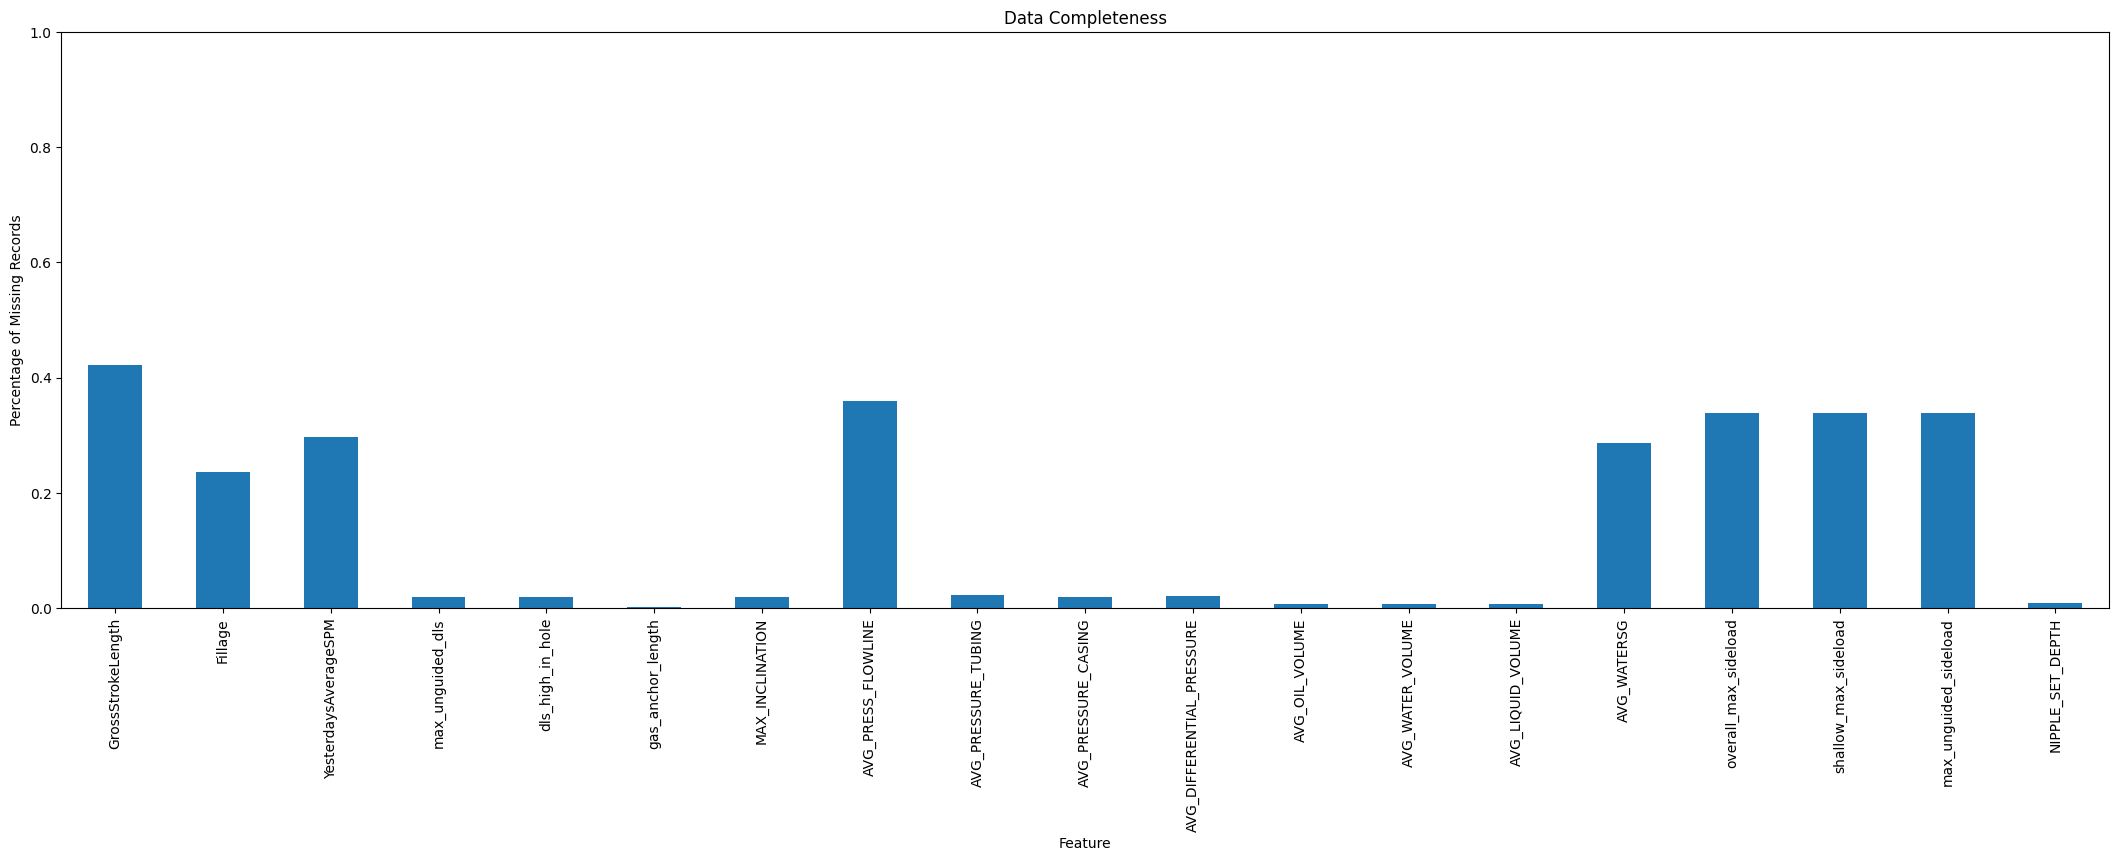

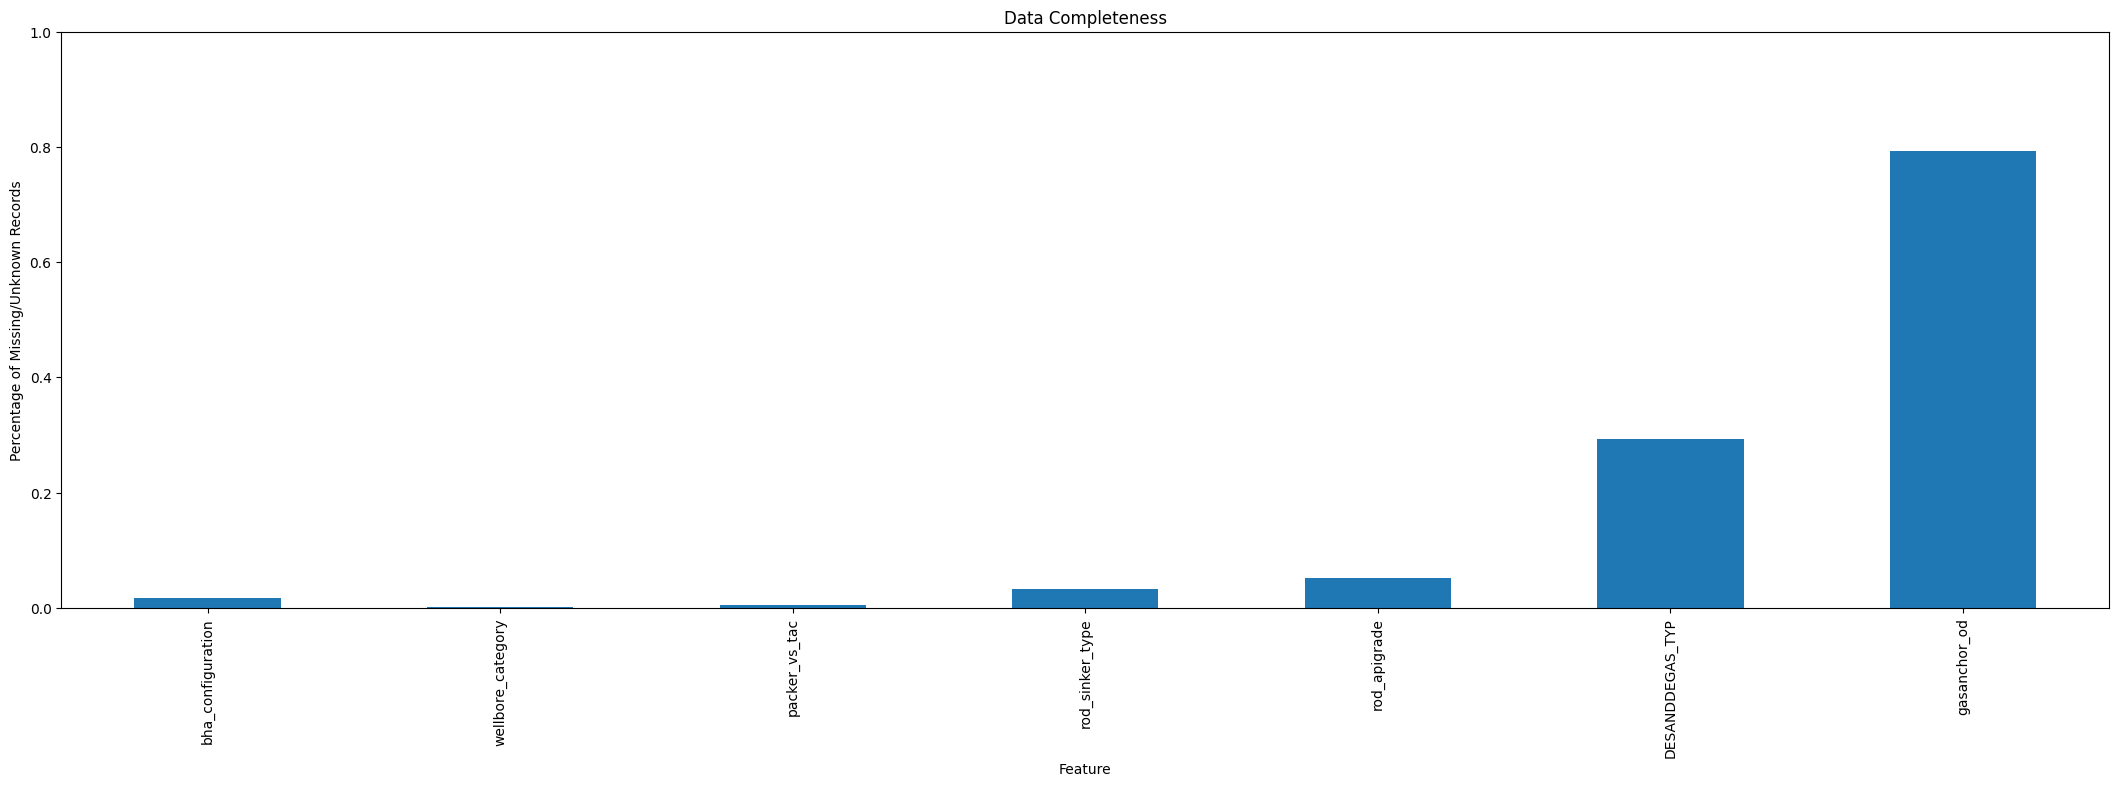

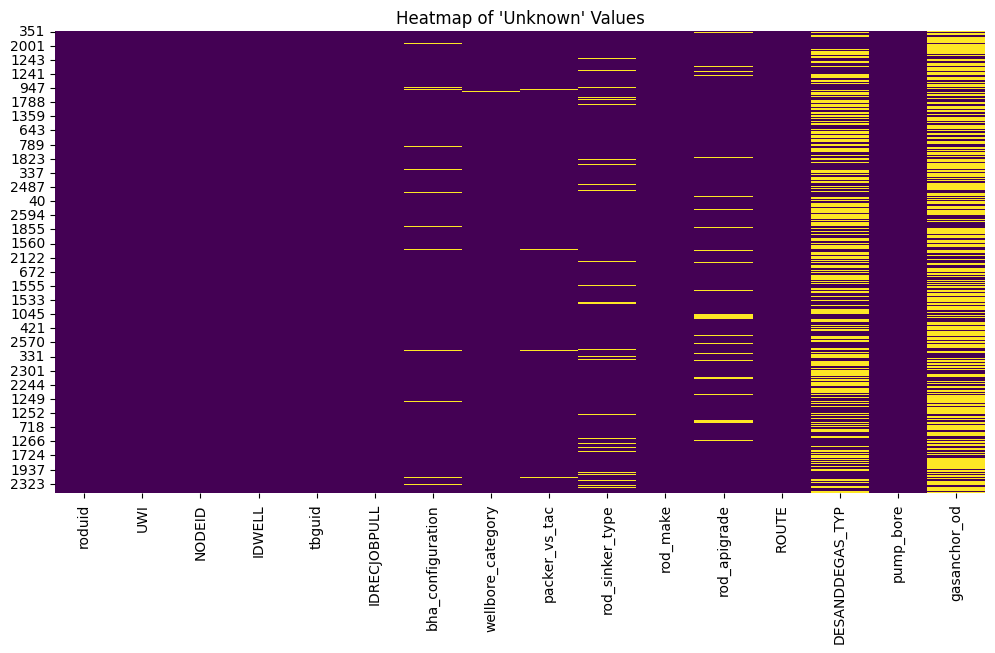

In [ ]:
### View Nulls, code taken from Prof Michael Pyrcz's Subsurface Data Analytics Demo

# numerical
df_num = df_num[df_num.columns[df_num.isna().any()]]
(df_num.isnull().sum()/len(df_num)).plot(kind = 'bar')
plt.subplots_adjust(left=0.0, bottom=0.0, right=3.2, top=1.2, wspace=0.2, hspace=0.2) # plot formatting
plt.xlabel('Feature'); plt.ylabel('Percentage of Missing Records'); plt.title('Data Completeness')
plt.ylim([0,1.0])
plt.show()

# categorical
# Count both null values and entries containing 'unknown' (case-insensitive)
missing_or_unknown = df_categorical.apply(
    lambda col: col.isnull().sum() + col.astype(str).str.lower().str.contains('unknown', na=False).sum()
)

# Calculate percentages and filter for values greater than 0
missing_pct = missing_or_unknown / len(df_categorical)
missing_pct = missing_pct[missing_pct > 0]

# Plot only features with missing/unknown values
missing_pct.plot(kind='bar')
plt.subplots_adjust(left=0.0, bottom=0.0, right=3.2, top=1.2, wspace=0.2, hspace=0.2)
plt.xlabel('Feature')
plt.ylabel('Percentage of Missing/Unknown Records')
plt.title('Data Completeness')
plt.ylim([0, 1.0])
plt.show()

# checks for 'UNKNOWN': (AI generated code)
unknown_mask = df_categorical.apply(
    lambda col: col.astype(str).str.contains('unknown', case=False, na=False)
).any(axis=1)

df_Unknown = df_categorical[unknown_mask].sort_values(by='UWI')

# Create heatmap highlighting cells with 'UNKNOWN'
heatmap_data = df_Unknown.apply(
    lambda col: col.astype(str).str.contains('unknown', case=False, na=False)
)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cbar=False, cmap="viridis")
plt.title("Heatmap of 'Unknown' Values")
plt.show()


In [ ]:
### Feature dropping/EDA
df.drop(['shallow_max_sideload', 'max_unguided_sideload','AVG_OIL_VOLUME', 'AVG_WATER_VOLUME','dls_high_in_hole'], axis=1, inplace=True) #multicollinear
df.drop('gasanchor_od', axis=1, inplace=True) #missing data
#messy outlier identified post-modeling - drop due to missing data
outlier_ind = df[(df['ROUTE'] == 884) & (df['WaterRatio'].round(6) == 0.298703) & (df['bha_configuration'] == 'PACKER_TAC_DONNAN')].index[0]
df = df.drop(outlier_ind)

#Check duplicate columns/ identifiers
print(df[['roduid']].value_counts().shape[0])
print(df[['UWI']].value_counts().shape[0])
print(df[['NODEID']].value_counts().shape[0])
print(df[['IDWELL']].value_counts().shape[0])
print(df[['tbguid']].value_counts().shape[0])
df.drop(['roduid', 'NODEID','IDWELL','IDRECJOBPULL','lifetime_end','PrimarySetpoint','SecondarySetpoint'], axis=1, inplace=True) #identifiers/control parameters

2577
633
632
633
1806


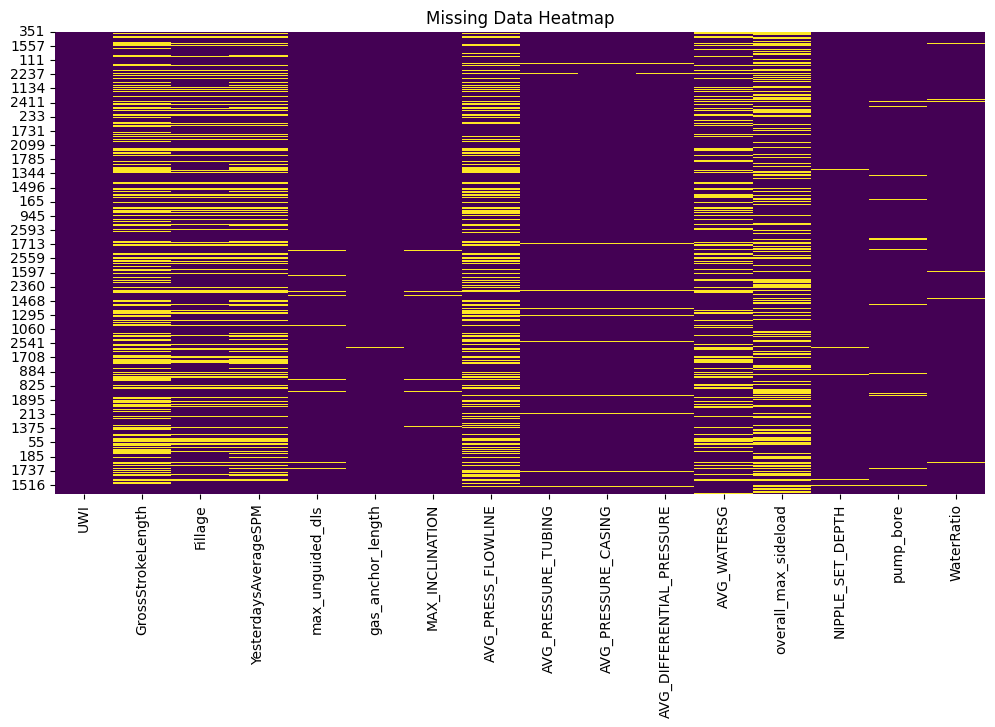

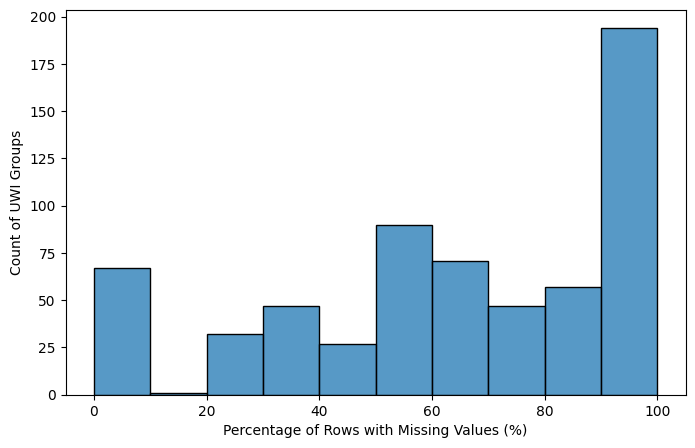

In [ ]:
### Continued null investigation
df_hasMissing = df[df.columns[df.isnull().any()]]
df_hasMissing = pd.concat([df[['UWI']], df_hasMissing], axis=1)
df_hasMissing = df_hasMissing.sort_values(by='UWI')
plt.figure(figsize=(12, 6))
sns.heatmap(df_hasMissing.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

# Investigate missing proportion by well (AI generated):
plot_df = (
    df.isnull().any(axis=1)
    .groupby(df['UWI'])
    .mean()
    * 100
).reset_index(name='Percentage Null Rows')

# Plot the distribution (histogram) using Seaborn
plt.figure(figsize=(8, 5))
sns.histplot(
    data=plot_df,
    x='Percentage Null Rows',
    bins=10, # Bins the percentages into 10 ranges
    kde=False # Ensures it's a bar chart (histogram)
)

# Set minimal labels
plt.xlabel('Percentage of Rows with Missing Values (%)')
plt.ylabel('Count of UWI Groups')
plt.show()

In [ ]:
### Chemgroup Feature Engineering
def calculate_score(row, group_num):
    any_col = f'chemgroup{group_num}_any'
    all_col = f'chemgroup{group_num}_all'

    if row[all_col] == 1:
        return 1
    elif row[any_col] == 1:
        return 0.5
    else:
        return 0

for i in range(1, 4):
    df[f'chemgroup{i}_score'] = df.apply(calculate_score, args=(i,), axis=1)

# Check for completeness
test_cols = []
for i in range(1, 4):
    test_cols.extend([f'chemgroup{i}_any', f'chemgroup{i}_all', f'chemgroup{i}_score'])

print(df[test_cols].head(10))

df.drop(['chemgroup1_any','chemgroup1_all','chemgroup2_any','chemgroup2_all','chemgroup3_any','chemgroup3_all'],axis = 1,inplace = True)

   chemgroup1_any  chemgroup1_all  chemgroup1_score  chemgroup2_any  \
0               1               1               1.0               1   
1               1               1               1.0               0   
2               0               0               0.0               0   
3               1               0               0.5               1   
4               1               0               0.5               0   
5               0               0               0.0               0   
6               0               0               0.0               1   
7               0               0               0.0               0   
8               0               0               0.0               0   
9               0               0               0.0               0   

   chemgroup2_all  chemgroup2_score  chemgroup3_any  chemgroup3_all  \
0               1               1.0               0               0   
1               0               0.0               0               0   
2    

In [ ]:
#@title Unused Code - Impute by tbguid, H2S Outlier Handling

## end date hist
#not sure if needed
# df['lifetime_end'] = pd.to_datetime(df['lifetime_end'])
# failed_data = df[df['FAILED'] == 0]
# failed_data['end_month'] = failed_data['lifetime_end'].dt.strftime('%Y-%m')

# sns.displot(
#     data=failed_data,
#     x='end_month',
#     kind='hist'
# )
# # plt.show()

# failed_data['end_month'].value_counts()

###########################################################

##this did not do anything...

#######################
# duplicate_tbguids = df['tbguid'].value_counts()
# duplicate_tbguids = duplicate_tbguids[duplicate_tbguids > 1]
# duplicate_tbguids
#######################

# dup_mask = df['tbguid'].duplicated(keep=False)  # rows where tbguid occurs >1

# if not dup_mask.any():
#     cols = []  # no non-unique tbguid values; nothing qualifies by your rule
# else:
#     per_tb = df.loc[dup_mask].groupby('tbguid', dropna=False).nunique(dropna=True)
#     per_tb = per_tb.drop(columns=['tbguid'], errors='ignore')
#     cols = per_tb.columns[per_tb.le(1).all(axis=0)].tolist()

# cols = ['tbguid'] + cols
# cols

# tbguid_distinct = df[df['tbguid'].duplicated(keep=False)][cols]
# cols2 = df_hasMissing.columns
# cols3 = set(cols).intersection(set(cols2))
# cols3 = []
# for val in cols:
#     if val in cols2:
#         cols3.append(val)

# imputable = df_hasMissing[df_hasMissing['tbguid'].isin(tbguid_distinct['tbguid'])][cols3]
# imputable_hasMissing = imputable[imputable.columns[imputable.isnull().any()]]
# imputable_hasMissing = pd.concat([imputable[['tbguid']], imputable_hasMissing], axis=1)
# imputable_hasMissing = imputable_hasMissing[imputable_hasMissing.isnull().any(axis=1)].sort_values('tbguid')
# imputable_hasMissing

# pairs = [
#     ('GB03QGGK89409334717138', 'bha_configuration'),
#     ('GB03QGGK89409334717138', 'packer_vs_tac'),
#     ('GB39IMBD14004485841632', 'bha_configuration'),
#     ('GB76JSBG22005613777819', 'dls_high_in_hole'),
#     ('GB34IAWR00801473389424', 'dls_high_in_hole'),
#     ('GB59TBLU66234759526744', 'dls_high_in_hole'),
#     ('GB63OWMS88587135100218', 'MAX_INCLINATION'),
#     ('GB26VDUL00145444367261', 'dls_high_in_hole'),
#     ('GB75KVEP62780964575853', 'MAX_INCLINATION'),
#     ('GB63OWMS88587135100218', 'packer_vs_tac'),
#     ('GB93WVAB08777013637684', 'NIPPLE_SET_DEPTH'),
#     ('GB87ORPF93447504238550', 'bha_configuration'),
#     ('GB51DQIU11064055184390', 'MAX_INCLINATION'),
#     ('GB79RFNR23805644693925', 'dls_high_in_hole'),
#     ('GB79RFNR23805644693925', 'MAX_INCLINATION'),
#     ('GB63OWMS88587135100218', 'NIPPLE_SET_DEPTH'),
#     ('GB75KVEP62780964575853', 'dls_high_in_hole'),
#     ('GB70OMDB01587059246777', 'MAX_INCLINATION'),
#     ('GB93WVAB08777013637684', 'MAX_INCLINATION'),
#     ('GB34IAWR00801473389424', 'MAX_INCLINATION'),
#     ('GB55DXHO49300642199527', 'dls_high_in_hole'),
#     ('GB27SZWN77912023293072', 'NIPPLE_SET_DEPTH'),
#     ('GB76JSBG22005613777819', 'MAX_INCLINATION'),
#     ('GB80XFMI22072646417353', 'bha_configuration'),
#     ('GB93WVAB08777013637684', 'bha_configuration'),
#     ('GB63OWMS88587135100218', 'gas_anchor_length'),
#     ('GB63OWMS88587135100218', 'bha_configuration'),
#     ('GB42YFXC67825906952021', 'bha_configuration'),
#     ('GB26VDUL00145444367261', 'MAX_INCLINATION'),
#     ('GB70OMDB01587059246777', 'dls_high_in_hole'),
#     ('GB21RKQC43411343105623', 'dls_high_in_hole'),
#     ('GB06OSFB80108562452539', 'dls_high_in_hole'),
#     ('GB94SXJN07751572478673', 'bha_configuration'),
#     ('GB03JYXI48003693592735', 'MAX_INCLINATION'),
#     ('GB79CONQ73000359863704', 'bha_configuration'),
#     ('GB06OSFB80108562452539', 'MAX_INCLINATION'),
#     ('GB32RGKC44366197376094', 'MAX_INCLINATION'),
#     ('GB03JYXI48003693592735', 'dls_high_in_hole'),
#     ('GB51DQIU11064055184390', 'dls_high_in_hole'),
#     ('GB21RKQC43411343105623', 'MAX_INCLINATION'),
#     ('GB15XVEJ26688513927863', 'NIPPLE_SET_DEPTH')
# ]

# for pair in pairs:
#   print(df[df['tbguid'] == pair[0]][pair[1]].mode())

###### H2S Outlier handling
# df['H2S_log1p'] = np.log1p(df['H2S_CONCENTRATION'])
# df.drop('H2S_CONCENTRATION', axis = 1, inplace = True)

# sns.boxplot(data=df,
#                 x='FAILED',
#                 y='H2S_log1p')
# plt.show()

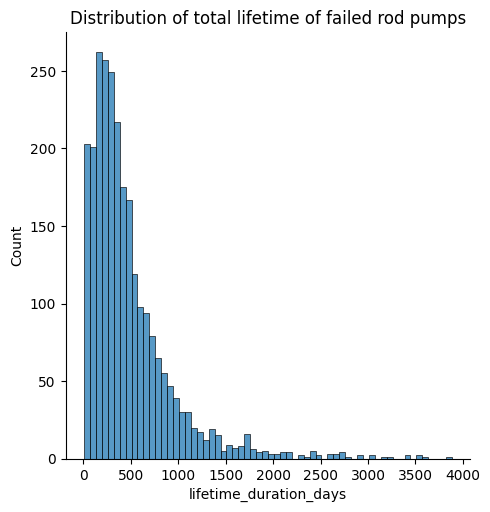

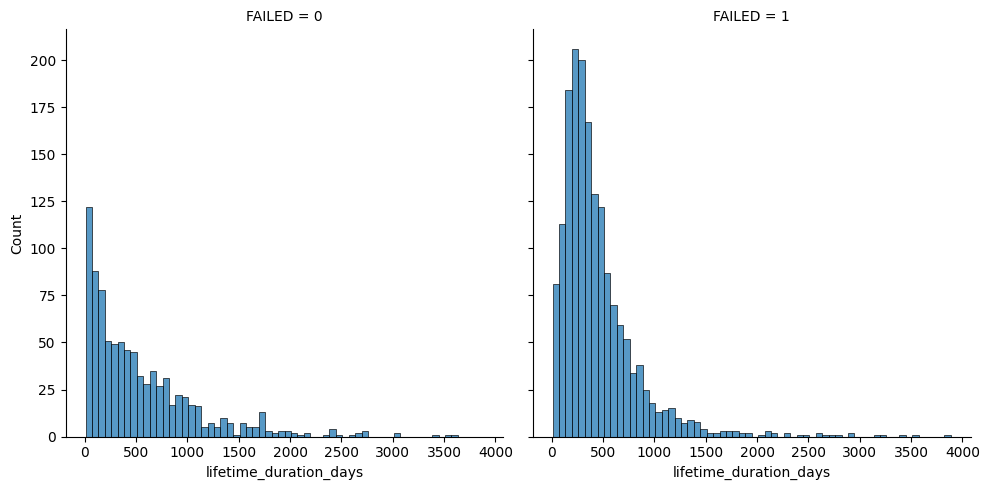

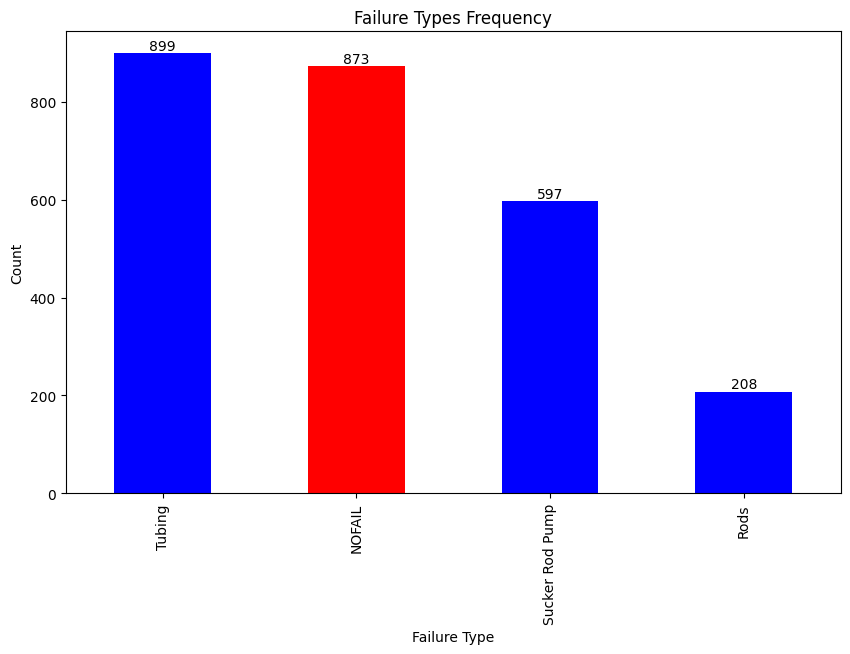

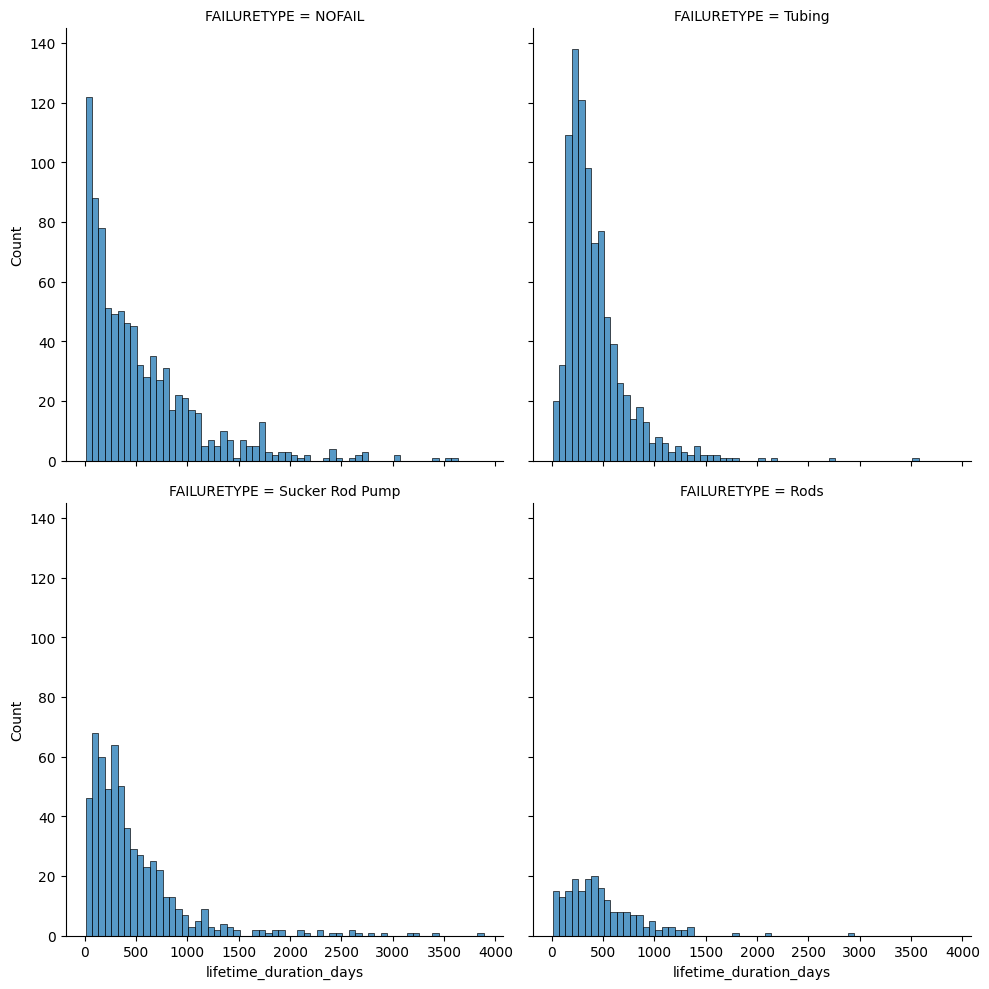

In [ ]:
### EDA of Failure Duration and Types

# lifetime
sns.displot(data=df, x="lifetime_duration_days")
plt.title("Distribution of total lifetime of failed rod pumps")
plt.show()

# lifetime by failure
sns.displot(
    data=df,
    x='lifetime_duration_days',
    col='FAILED',
    kind='hist',
    col_wrap=2
)
plt.show()

# failure types count
counts = df['FAILURETYPE'].value_counts()
colors = ['blue'] * 4  # Default color for all bars
colors[1] = 'red'  # Set the highlight color
ax = counts.plot(kind='bar', figsize=(10,6), color = colors)

for bar in ax.patches:
    yval = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.5,
        int(yval),
        ha='center', va='bottom'
    )

plt.xlabel("Failure Type")
plt.ylabel("Count")
plt.title("Failure Types Frequency")
plt.xticks(rotation=90)
plt.show()


# lifetime histogram, faceted by failuretype
sns.displot(
    data=df,
    x='lifetime_duration_days',
    col='FAILURETYPE',
    kind='hist',
    col_wrap=2
)
plt.show()

In [ ]:
### export
from google.colab import files
df.to_csv('preFS_df.csv', index=False)
# files.download('preFS_df.csv') #uncomment to export
df.head()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,UWI,tbguid,lifetime_start,FAILURETYPE,H2S_CONCENTRATION,StrokeLength,GrossStrokeLength,Fillage,YesterdaysAverageSPM,bha_configuration,...,ENDURALLOY_LENGTH,POLY_LENGTH,NIPPLE_SET_DEPTH,pump_bore,FAILED,lifetime_duration_days,WaterRatio,chemgroup1_score,chemgroup2_score,chemgroup3_score
0,175-58-0111,GB55QFGB46756147811400,2014-05-02 00:00:00,Tubing,0.0,144.000000,108.135619,91.410156,6.000000,TAC_ABOVE_NIP,...,0.00,0.0,10024.8,1.5,1,1708.42,0.536177,1.0,1.0,0.0
1,333-68-3523,GB29QCCC14341267287129,2018-01-28 14:00:00,Tubing,0.0,168.000000,173.462417,2.500000,0.000000,TAC_BELOW_NIP,...,0.00,0.0,10235.6,1.5,1,473.92,0.159911,1.0,0.0,0.0
2,165-51-5897,GB02DJAW44801752494129,2011-09-14 00:00:00,Sucker Rod Pump,0.0,144.000000,NaN,NaN,NaN,PACKER_DONNAN,...,0.00,0.0,10401.9,1.5,1,341.00,0.182080,0.0,0.0,0.0
3,543-56-3494,GB84GHPH97287631470412,2016-01-12 09:00:00,Sucker Rod Pump,0.0,144.199997,NaN,86.327774,5.800000,TAC_ABOVE_NIP,...,0.00,0.0,9557.7,1.75,1,429.31,0.248524,0.5,0.5,0.0
4,391-37-2039,GB08VYTX61977431827206,2018-06-14 13:00:00,NOFAIL,0.0,168.000000,127.228453,61.000000,4.272727,TAC_BELOW_NIP,...,129.39,0.0,9681.7,1.75,0,671.19,0.170469,0.5,0.0,0.0
